In [ ]:
import pandas as pd
from hiprof.base.graph import Graph
from hiprof.verification.falsifier import HPFalsifier

See Figure 1.12 in [Bareinboim, Correa, Ibeling, Icard (2022). On Pearl's Hierarchy and the Foundations of Causal Inference.](https://causalai.net/r60.pdf)

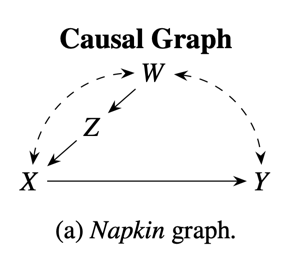

In [ ]:
nodes = ["W", "Z", "X", "Y"]
directed = pd.DataFrame(
    [[0, 1, 0, 0],
     [0, 0, 1, 0],
     [0, 0, 0, 1],
     [0, 0, 0, 0]],
    index=nodes,
    columns=nodes,
)
bidirected = pd.DataFrame(
    [[0, 0, 1, 1],
     [0, 0, 0, 0],
     [1, 0, 0, 0],
     [1, 0, 0, 0]],
    index=nodes,
    columns=nodes,
)
graph = Graph(directed=directed, bidirected=bidirected)

In [ ]:
formula = "INT_{W} { p(Y, X | Z, W) p(W) } / INT_{W} { p(X | Z, W) p(W) }"
falsifier = HPFalsifier(treatments='X', outcomes='Y', graph=graph)
falsifier.check(formula)

In [ ]:
formula = "p(Y | X=.)"
falsifier.check(formula)